# Exploratory Data Analysis of Olist brazilian E-commerce Dataset :

## Phase 1 : Data Preprocessing and Preparation :

#### 1. Preparing the Environment and Dataset Extraction Pipeline

#### 1.1. Import necessary dependencies 

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import scipy.stats as stats
from matplotlib import pyplot as plt

import os
import pyarrow
from google.cloud import bigquery

from dotenv import load_dotenv

print('done!')

done!


#### 1.2. Variables Loading From Env File

In [2]:
load_dotenv()
MY_PROJECT_ID = os.getenv("BIGQUERY_PROJECT_ID")
DATASET_NAME = os.getenv("DATASET_NAME")

# local workspace folder 
OUTPUT_DIR = os.getenv("RAW_DATA_PATH")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Variables loaded successfully!')

Variables loaded successfully!


#### 1.3. Extracting Dataset Tables From BigQuery

In [3]:
# Establish client tracking 
client = bigquery.Client(project=MY_PROJECT_ID)

# extraction pipeline 
print(f"Connecting to Sandbox project container: {MY_PROJECT_ID}...")

try:
    # Reference local data schema path
    dataset_ref = client.dataset(DATASET_NAME, project=MY_PROJECT_ID)
    tables = client.list_tables(dataset_ref)
    
    print("Connection active! Commencing loop download to local storage...\n")
    
    # automatically catches all tables in dataset:
    for i, table in enumerate(tables):
        table_name = table.table_id
        if not os.path.exists(os.path.join(OUTPUT_DIR, f"{table_name}.csv")):
            print(f"Streaming -> Table: '{table_name}' into data frame...")
            
            # Pulling rows using SQL queries
            query = f"SELECT * FROM `{MY_PROJECT_ID}.{DATASET_NAME}.{table_name}`"
            df = client.query(query).to_dataframe()
            
            # destination filename 
            csv_destination_file = os.path.join(OUTPUT_DIR, f"{table_name}.csv")
            
            print(f'saving as CSV table number "{i}" :{table_name} ...')
            # Save as a standard local CSV format
            df.to_csv(csv_destination_file, index=False)
            print(f"   Saved successfully to: {csv_destination_file}")
        else :
            print(f'table {table_name} already extracted and saved as CSV file')
    print("\nExtraction pipeline complete!")
    print(f"All tables shown in your tree are downloaded locally!")

except Exception as e:
    print(f"\n[ERROR] Pipeline run failed: {e}")

Connecting to Sandbox project container: bigquery-public-dataset-500516...
Connection active! Commencing loop download to local storage...

table olist_customer already extracted and saved as CSV file
table olist_geolocation already extracted and saved as CSV file
table olist_order_items already extracted and saved as CSV file
table olist_order_payments already extracted and saved as CSV file
table olist_order_reviews already extracted and saved as CSV file
table olist_orders already extracted and saved as CSV file
table olist_products already extracted and saved as CSV file
table olist_sellers already extracted and saved as CSV file

Extraction pipeline complete!
All tables shown in your tree are downloaded locally!


#### 1.4. Archiving the Dataframes in a Dictionary

In [4]:
dict_datasets_dfs = {}
for file_name in os.listdir(OUTPUT_DIR) :
    if file_name.endswith('.csv'):
        file_path = os.path.join(OUTPUT_DIR, file_name)
        df_key = file_name.replace('.csv', '').replace('olist_', '')
        globals()[f'df_{df_key}'] = pd.read_csv(file_path)
        df_name = globals()[f'df_{df_key}'] 
        dict_datasets_dfs[df_key] = df_name
        
print('all dfs created seccussfully!')

all dfs created seccussfully!


#### 2. Datasets Pre-Processing, manipulating and Cleaning :

#### 2.1. Datasets Overview Duplicated Rows and Primary Key

In [5]:
dict_duplication_check = {}
for dataset, df in dict_datasets_dfs.items():
    total_duplicated_rows = df.duplicated().sum()
    id_column = df.columns[0]
    total_duplicated_ids = df[id_column].duplicated().sum()
    
    dict_duplication_check[dataset] = [total_duplicated_rows, total_duplicated_ids]

df_summary = pd.DataFrame.from_dict(dict_duplication_check,
                                    orient='index',
                                    columns = ['count of duplicated rows', 
                                               'count of duplicated ids']
                                    )
df_summary  

,count of duplicated rows,count of duplicated ids
customer,0,0
geolocation,261831,981148
orders,0,0
order_items,0,13984
order_payments,0,4446
order_reviews,0,0
products,0,0
sellers,0,0


### Data Diagnostics & Geolocation Strategy Analysis

#### 1. Diagnostic Observations of Duplications
Our initial data diagnostics revealed varying levels of duplications across the dataset:
* **Unique Dimension Tables (`customer`, `orders`, `products`, `sellers`, `order_reviews`)**: These tables show `0` duplicated rows and `0` duplicated ID columns, confirming they function correctly as unique dimension tables.
* **Transaction Tables (`order_items`, `order_payments`)**: These tables contain `0` fully duplicated rows, but show duplicate IDs (`order_id`). This represents a natural **one-to-many (1:N)** relationship where a single order can contain multiple items (13,984 cases) or involve split payment transactions (4,446 cases).
* **The Geolocation Table**: This table contains a massive volume of duplicate zip codes (981,148 duplicate IDs). This happens because a zip code prefix in Brazil represents a neighborhood, and the dataset records multiple coordinate logs (different street pings) under the same zip code prefix.

---

#### 2. The Geolocation Join Challenge
It is tempting to suggest merging latitude and longitude into a single `coordinates` column to use as a primary key. However, this is not feasible in practice because:
* **Lack of Coordinate Data in Dimensions**: Due to customer privacy standards and standard database design, the `customer` and `seller` tables do not store coordinate data.
* **The Only Bridge**: The only shared attribute connecting customers/sellers to their location is the `zip_code_prefix`.
* **The Cartesian Product Risk**: If we perform a direct join on the raw, unaggregated `geolocation` table using the zip code prefix, a single customer row will match hundreds of coordinate rows for that zip code. This would trigger a **Cartesian Product explosion**, artificially multiplying our customer and sales metrics.

Consequently, we must choose between two strategies: **dropping the coordinates entirely** or **aggregating them**.

---

#### 3. Why Aggregation is Superior to Dropping
While dropping the latitude and longitude columns would simplify the schema, keeping and aggregating them is highly recommended because it expands our analytical scope:
* ** unlocks Spatial Analysis**: Retaining coordinates allows us to calculate the **geodesic distance (km)** between sellers and customers for every order. This is a critical metric for analyzing delivery times, shipping costs, and logistics bottlenecks.
* **Enables Geographic Visualization**: Collapsing coordinates into unique points allows us to safely build customer density heatmaps and regional sales bubble maps in BI tools without duplicating sales numbers.

---

#### 4. Mathematical Validity of Coordinate Aggregation
To resolve the duplication while preserving geographic context, we aggregate the coordinates by calculating the **arithmetic mean (average)** of latitude and longitude for each unique zip code prefix. 

* **Why it works mathematically**: Because coordinate points within a single zip code prefix are clustered closely together (usually within a few square kilometers), the curvature of the Earth is negligible. The arithmetic mean serves as a highly accurate approximation of the **geographic centroid** (the center point of the neighborhood).
* **Industry Standard**: Collapsing multiple coordinates into a single centroid per geographic boundary (like a zip code or census tract) is the standard best practice in spatial data science and Business Intelligence (BI) modeling.


#### 2.2. Preprocessing tables 

#### 2.2.1. Olist Geolocation table :

In [6]:
# dropping duplicated rows from the table
df_geolocation.drop_duplicates(inplace = True)
df_geolocation.info()

<class 'pandas.DataFrame'>
Index: 738332 entries, 0 to 1000159
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  str    
 4   geolocation_state            738332 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 42.8 MB


In [7]:
# agg the coordinates columns as Avg 
df_geolocation['geolocation_lat'] = df_geolocation.groupby('geolocation_zip_code_prefix')['geolocation_lat'].transform('mean')
df_geolocation['geolocation_lng'] = df_geolocation.groupby('geolocation_zip_code_prefix')['geolocation_lng'].transform('mean')
df_geolocation.duplicated().sum()

np.int64(710420)

### Resolving String Variations with Subset Deduplication

Now after agg the geolocation coordinates, now we are going to drop the duplicates. But a standard `.drop_duplicates()` command checks for rows where *every single column* is identical. However, in our geolocation dataset, some rows sharing the same zip code contain slight string variations in the city names (e.g., `"sao paulo"` vs. `"são paulo"` due to accents or typos). 

Because Python treats these as completely different strings, a standard drop-duplicate check fails to merge them, leaving duplicate zip code prefixes in our table.

To resolve this, we use `subset=['geolocation_zip_code_prefix']`. This instructs Pandas to strictly enforce uniqueness on the zip code column alone, keeping the first occurrence and safely discarding any duplicate rows caused by minor text spelling variations.


In [8]:
# dropping duplicated rows keeping only the first row, reset index
df_geolocation = df_geolocation.drop_duplicates(subset=['geolocation_zip_code_prefix'])\
                               .reset_index(drop=True)


# converting str columns to category dtype
targeted_columns = ['geolocation_city', 'geolocation_state']
df_geolocation[targeted_columns] = df_geolocation[targeted_columns].astype('category')

# converting geolocation_zip_code_prefix from int64 dtype to int32 :
df_geolocation['geolocation_zip_code_prefix'] = df_geolocation['geolocation_zip_code_prefix'].astype('int32')

# final check
df_geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   geolocation_zip_code_prefix  19015 non-null  int32   
 1   geolocation_lat              19015 non-null  float64 
 2   geolocation_lng              19015 non-null  float64 
 3   geolocation_city             19015 non-null  category
 4   geolocation_state            19015 non-null  category
dtypes: category(2), float64(2), int32(1)
memory usage: 544.0 KB


#### 2.2.2. Olist Orders and Customers tables :

In [9]:
df_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [10]:
# checking duplicates customer_unique_id :
df_customer['customer_unique_id'].duplicated().sum()

np.int64(3345)

In [11]:
#checking duplicated rows in df_customer dataframe
df_orders['customer_id'].duplicated().sum()

np.int64(0)

### Normalizing the Customer and Orders Tables

#### Diagnostic Observation
During initial database diagnostics, we observed a crucial pattern in the customer table (`olist_customer`):
* **Total Rows:** 99,441
* **Unique `customer_id` values:** 99,441 (100% unique)
* **Unique `customer_unique_id` values:** 96,096 (containing 3345 repeat customers)

This reveals that **`customer_id`** is not a unique identifier for a physical customer, but rather a unique key generated for **each individual shopping session/order**. Because of this structure, customer details (zip code, city, and state) are needlessly duplicated for every order a customer makes.

#### The Normalization Strategy
To align our database with professional dimensional modeling standards (specifically a **Star Schema**), we will restructure the tables into a clean parent-child relationship:
1. **`df_orders` (Fact Table):** Will store the transactions, referencing the customer using **`customer_unique_id`** as the foreign key.
2. **`df_customer` (Dimension Table):** Will serve as a clean dimension table where **`customer_unique_id`** is the primary key (exactly one row per physical customer).

#### Execution Plan
1. **Join the Tables:** Left-join `df_orders` with `df_customer` using `customer_id` to bring `customer_unique_id` into the orders table.
2. **Drop Redundant Keys:** Remove `customer_id` from both dataframes.
3. **Deduplicate Dimension Table:** Run `.drop_duplicates(subset=['customer_unique_id'])` on `df_customer` to ensure primary key uniqueness.

#### Analytical Trade-off
Our analysis showed that only **250 out of 96,096 customers (0.26%)** purchased items from different zip code prefixes over time. By deduplicating the customer table, we will retain only one primary profile address per customer. This minor loss of location history is an standard industry trade-off, as the simplification of the data model heavily outweighs the storage of duplicate demographic data.


In [12]:
df_orders = df_orders.merge(
    df_customer[['customer_id', 'customer_unique_id']],
    on = 'customer_id',
    how = 'left'
)
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
 8   customer_unique_id             99441 non-null  str  
dtypes: str(9)
memory usage: 28.6 MB


In [13]:
# 1. Drop the temporary customer_id column since customer_unique_id is now the foreign key
df_orders.drop(columns=['customer_id'], inplace=True)

# 2. Extract (pop) the customer_unique_id column to temporarily store it
customer_unique_id_col = df_orders.pop('customer_unique_id')

# 3. Re-insert the popped column at index 1 (directly after order_id)
df_orders.insert(1, 'customer_unique_id', customer_unique_id_col)

# 4. rename and uniforming date columns
df_orders.rename( columns = {'order_approved_at':'order_approved_date',
                             'order_purchase_timestamp' : 'order_purchase_date'}, 
                             inplace = True
                )
# 5. data type changing 
# 5.1. categorical columns 
df_orders['order_status'] = df_orders['order_status'].astype('category')

# 5.2. datetime columns
targeted_date_cols = [col for col in df_orders.columns if 'date' in col.lower()]
df_orders[targeted_date_cols] = df_orders[targeted_date_cols].apply(pd.to_datetime)

# 5. Update the dataframe inside the tracking dictionary
dict_datasets_dfs['orders'] = df_orders

# 6. Verification fo the results 
df_orders.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   order_id                       99441 non-null  str                
 1   customer_unique_id             99441 non-null  str                
 2   order_status                   99441 non-null  category           
 3   order_purchase_date            99441 non-null  datetime64[us, UTC]
 4   order_approved_date            99281 non-null  datetime64[us, UTC]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us, UTC]
 6   order_delivered_customer_date  96476 non-null  datetime64[us, UTC]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us, UTC]
dtypes: category(1), datetime64[us, UTC](5), str(2)
memory usage: 11.5 MB


In [14]:
df_orders['order_status'].unique().tolist()

['approved',
 'canceled',
 'created',
 'delivered',
 'invoiced',
 'processing',
 'shipped',
 'unavailable']

In [15]:
df_orders.head()

,order_id,customer_unique_id,order_status,order_purchase_date,order_approved_date,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,a2e4c44360b4a57bdff22f3a4630c173,7b9d52d22310baecad0f9df64872208d,approved,2017-02-06 20:18:17+00:00,2017-02-06 20:30:19+00:00,NaT,NaT,2017-03-01 00:00:00+00:00
1,132f1e724165a07f6362532bfb97486e,6a068ccd3a149b5c8ceb4e04c83feb8a,approved,2017-04-25 01:25:34+00:00,2017-04-30 20:32:41+00:00,NaT,NaT,2017-05-22 00:00:00+00:00
2,809a282bbd5dbcabb6f2f724fca862ec,009b0127b727ab0ba422f6d9604487c7,canceled,2016-09-13 15:24:19+00:00,2016-10-07 13:16:46+00:00,NaT,NaT,2016-09-30 00:00:00+00:00
3,e5215415bb6f76fe3b7cb68103a0d1c0,281096eb031de8c318bba51915fdd16a,canceled,2016-10-22 08:25:27+00:00,NaT,NaT,NaT,2016-10-24 00:00:00+00:00
4,71303d7e93b399f5bcd537d124c0bcfa,0eb1ee9dba87f5b36b4613a65074337c,canceled,2016-10-02 22:07:52+00:00,2016-10-06 15:50:56+00:00,NaT,NaT,2016-10-25 00:00:00+00:00


#### Analysis of missing date values in orders table :

In [16]:
list_status = [
    ['created'],
    ['approved',
    'invoiced',
    'processing'],
    ['shipped'],
    ['delivered'],
    ['canceled'],
    ['unavailable']
]
date_cols = [col for col in df_orders.columns if 'date' in col.lower()]
for status in list_status :
    df_status = df_orders[df_orders['order_status'].isin(status)]
    print(f'for status {status} :')
    print(df_status[date_cols].notna().sum())
    print(f'\n{"="*40}') 

for status ['created'] :
order_purchase_date              5
order_approved_date              0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    5
dtype: int64

for status ['approved', 'invoiced', 'processing'] :
order_purchase_date              617
order_approved_date              617
order_delivered_carrier_date       0
order_delivered_customer_date      0
order_estimated_delivery_date    617
dtype: int64

for status ['shipped'] :
order_purchase_date              1107
order_approved_date              1107
order_delivered_carrier_date     1107
order_delivered_customer_date       0
order_estimated_delivery_date    1107
dtype: int64

for status ['delivered'] :
order_purchase_date              96478
order_approved_date              96464
order_delivered_carrier_date     96476
order_delivered_customer_date    96470
order_estimated_delivery_date    96478
dtype: int64

for status ['canceled'] :
order_purchase_date              625
order_a

### Analysis of Missing Values in Date Columns

During analysis, we noticed missing values (nulls) in `order_approved_at`, `order_delivered_carrier_date`, and `order_delivered_customer_date`. 

#### Observation: Structural Missingness Verified by Status Analysis
These missing values are not data collection errors. Instead, they represent structural missingness dictated by the natural lifecycle of an e-commerce order 

By grouping the orders by their status and checking the presence of date records, we verified that these missing values are not data collection errors. Instead, they represent structural missingness dictated by the natural lifecycle of an e-commerce order (Created -> Approved -> Shipped -> Delivered):

* **created**: Only the purchase date and estimated delivery date are present. Other dates are empty because payment has not yet been processed or approved.
* **approved, invoiced, processing**: The purchase date, approval date, and estimated delivery date are present. The carrier and customer delivery dates are empty because the items have not yet left the warehouse.
* **shipped**: The purchase date, approval date, carrier handoff date, and estimated delivery date are present. The customer delivery date is empty because the package is still in transit.
* **delivered**: All dates are present, representing successfully completed lifecycles. A very small number of exceptions exist due to minor database logging anomalies.
* **canceled**: Dates are populated only up to the point where the cancellation occurred, showing that orders can be aborted at different stages of the flow (before approval, after approval but before shipping, or while in transit).
* **unavailable**: The purchase date, approval date, and estimated delivery date are present, but carrier and customer delivery dates are empty because fulfillment was stopped due to stock unavailability.
#### Handling Strategy
* **No Imputation:** We will not fill these missing dates with statistical averages (like mean or median), as that would corrupt our shipping and delivery duration calculations.
* **Contextual Filtering:** We will handle missing dates dynamically depending on the analysis (for example, filtering for successfully delivered orders when analyzing delivery speed).

In [17]:
# 1. Drop the customer_id column 
df_customer.drop(columns=['customer_id'], 
                 inplace=True)

# 2. Keep only unique customer profiles based on their unique ID
df_customer.drop_duplicates(subset=['customer_unique_id'], 
                            inplace=True)

# 3. refining the data type
targeted_cols = ['customer_city', 'customer_state']
df_customer[targeted_cols] = df_customer[targeted_cols].astype('category')
df_customer['customer_zip_code_prefix'] = df_customer['customer_zip_code_prefix'].astype('int32')

# 4. Update the cleaned customer dataframe in the tracking dictionary
dict_datasets_dfs['customer'] = df_customer

# 5. verification the results 
df_customer.info()

<class 'pandas.DataFrame'>
Index: 96096 entries, 0 to 99440
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   customer_unique_id        96096 non-null  str     
 1   customer_zip_code_prefix  96096 non-null  int32   
 2   customer_city             96096 non-null  category
 3   customer_state            96096 non-null  category
dtypes: category(2), int32(1), str(1)
memory usage: 5.1 MB


##### Next, we will verify whether all customer zip code prefixes exist in the geolocation table. It is essential to ensure complete coverage because the geolocation table serves as the primary dimension table for our geographical analysis. If a customer's zip code is missing from this lookup table, any geographical joins or dashboard slicers would exclude that customer's records, leading to incomplete sales and demographic reports.


In [18]:
# 1. Perform a right join between the geolocation and customer tables 
# (This brings in all customer records, matching them with geolocation coordinates where possible)
df_customer_to_geo = df_geolocation.merge(
    df_customer[['customer_zip_code_prefix',
                 'customer_city',
                 'customer_state'
                  ]],
    left_on = 'geolocation_zip_code_prefix',
    right_on = 'customer_zip_code_prefix',
    how = 'right'
)

# 2. Filter for rows where the geolocation join failed (indicated by NaN values in geolocation_city)
# and select only the customer columns to check their details
df_customer_to_geo = df_customer_to_geo[df_customer_to_geo['geolocation_city'].isna()][
    [
        'customer_zip_code_prefix',
        'customer_city',
        'customer_state'
    ]
].reset_index(drop = True)

# 3. Deduplicate the resulting dataframe to get a unique list of missing zip code prefixes
df_customer_to_geo = df_customer_to_geo.drop_duplicates()\
                                       .reset_index(drop=True)

# 4. Display the unique missing records
df_customer_to_geo


,customer_zip_code_prefix,customer_city,customer_state
0,57254,luziapolis,AL
1,41098,salvador,BA
2,41347,salvador,BA
3,42716,lauro de freitas,BA
4,42843,jaua,BA
...,...,...,...
152,12770,pinheiros,SP
153,13307,itu,SP
154,17390,sao sebastiao da serra,SP
155,19740,bora,SP


In [19]:
# 1. Create a renaming mapping to change 'customer_' column prefixes to 'geolocation_' 
renaming_columns = {col: col.replace('customer', 'geolocation')
                    for col in df_customer_to_geo.columns}

# 2. Rename the columns of the missing records in-place
df_customer_to_geo.rename(columns=renaming_columns, inplace=True)

# 3. Concatenate (append) the resolved missing records to the master geolocation dataframe
df_geolocation = pd.concat([df_geolocation, df_customer_to_geo],
                           ignore_index=True)

# 4. Impute missing coordinates (lat/lng) using the average (mean) coordinates of their respective states
for col in ['geolocation_lat', 'geolocation_lng']:
    mean = df_geolocation.groupby('geolocation_state')[col].transform('mean')
    df_geolocation[col] = df_geolocation[col].fillna(mean)
    
# 5. Save the updated master geolocation dataframe back into the tracking dictionary
dict_datasets_dfs['geolocation'] = df_geolocation

# 6. Verify the final schema and ensure all missing locations are fully resolved
df_geolocation.info()


<class 'pandas.DataFrame'>
RangeIndex: 19172 entries, 0 to 19171
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   geolocation_zip_code_prefix  19172 non-null  int32   
 1   geolocation_lat              19172 non-null  float64 
 2   geolocation_lng              19172 non-null  float64 
 3   geolocation_city             19172 non-null  str     
 4   geolocation_state            19172 non-null  category
dtypes: category(1), float64(2), int32(1), str(1)
memory usage: 741.6 KB


#### 2.2.3. Olist Products table :

In [20]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB


In [21]:
# columns to correct spelling : "length" not "lenght" 
df_products.columns = df_products.columns.str.replace('lenght', 
                                                      'length', 
                                                       regex = False)

#### Analysis of Missing Values in Products Table

During our check of the products table (`olist_products`), we identified missing values in several columns, including product categories, description lengths, weight, and dimensions.

#### Summary of our findings :
We performed an integrity check to see if the products with missing categories were associated with actual sales in the transaction tables. 

Which these products representing or could  represent a significant amount of revenue. If we drop these product rows, any subsequent join between sales and products will discard those transactions, leading to an underreporting of total sales and revenue.

#### Handling Strategy
To maintain referential integrity and keep our financial metrics accurate, we will keep these rows and impute the missing values:

* **product_category_name:** Fill missing values with a placeholder label (such as `'unknown'`) to preserve the relationship with sales records while marking them as uncategorized.
* **product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm:** Fill missing values with the median.

In [22]:
# 1. Fill missing product categories with 'unknown' and convert the column to category dtype
df_products['product_category_name'] = df_products['product_category_name'].fillna('unknown')\
                                                                           .astype('category')

# 2. Identify integer columns representing listing text lengths and photo quantities
int_cols = [col for col in df_products.columns 
            if col.endswith('_length') 
            or col.endswith('_qty')]          

# 3. Fill missing values in integer columns with their median (rounded to 0 decimals) and cast to int64
for col in int_cols:
    median = round(df_products[col].median(), 0)
    df_products[col] = df_products[col].fillna(median)\
                                       .astype('int16')

# 4. Identify float columns representing product weight (grams) and dimensions (centimeters)
float_cols = [col for col in df_products.columns 
              if col.endswith('_g')
              or col.endswith('_cm')]

# 5. Fill missing values in float columns with their median (rounded to 2 decimals)
for col in float_cols: 
    median = round(df_products[col].median(), 2)
    df_products[col] = df_products[col].fillna(median)\
                                       .astype('float32')

# 6. save changes to  the tracking dictionary 
dict_datasets_dfs['products'] = df_products

# 7. verification of the results 
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   product_id                  32951 non-null  str     
 1   product_category_name       32951 non-null  category
 2   product_name_length         32951 non-null  int16   
 3   product_description_length  32951 non-null  int16   
 4   product_photos_qty          32951 non-null  int16   
 5   product_weight_g            32951 non-null  float32 
 6   product_length_cm           32951 non-null  float32 
 7   product_height_cm           32951 non-null  float32 
 8   product_width_cm            32951 non-null  float32 
dtypes: category(1), float32(4), int16(3), str(1)
memory usage: 2.0 MB


### 2.2.4. Olist Sellers table :

In [23]:
df_sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 230.3 KB


In [24]:
df_sellers['seller_city'].unique().tolist()

['sao paulo sp',
 'sao pauo',
 'sp / sp',
 'sao paulo / sao paulo',
 'sao paulop',
 'sao paulo - sp',
 'são paulo',
 'sp',
 'pirituba',
 'sao  paulo',
 'carapicuiba / sao paulo',
 'carapicuiba',
 'barueri',
 'santana de parnaiba',
 'itapevi',
 'cotia',
 'vargem grande paulista',
 'taboao da serra',
 'tabao da serra',
 'embu das artes',
 'itapecerica da serra',
 'embu guacu',
 'garulhos',
 'aruja',
 'mairipora',
 'caieiras',
 'cajamar',
 'franco da rocha',
 'francisco morato',
 'sao paluo',
 'ferraz de vasconcelos',
 'ferraz de  vasconcelos',
 'poa',
 'itaquaquecetuba',
 'suzano',
 'mogi das cruses',
 'mogi das cruzes / sp',
 'sando andre',
 'santo andre/sao paulo',
 'maua',
 'maua/sao paulo',
 'ribeirao pires',
 'ao bernardo do campo',
 'sao bernardo do capo',
 'sbc/sp',
 'sbc',
 'diadema',
 'bertioga',
 'sao vicente',
 'guaruja',
 'vicente de carvalho',
 'sao sebastiao',
 'ubatuba',
 'praia grande',
 'registro',
 'cananeia',
 'taubate',
 'monteiro lobato',
 'jambeiro',
 'jacarei / sa

### Normalization of the Sellers Table Location Data

#### The Problem with the Current Structure
The raw `df_sellers` table contains `seller_city` and `seller_state` columns. Upon inspection, these columns contain numerous data entry errors, including typos, abbreviations, nested state names, and invalid inputs.

#### Justification for Column Removal (Database Normalization)
In database design, storing the city and state names directly in the sellers table violates normalization principles (specifically Third Normal Form). 

Since a 5-digit zip code prefix is geographically assigned to a single city, the city and state are transitively dependent on the zip code prefix. Storing them in the sellers table creates redundant data and leads to the data entry discrepancies we observed.

#### Geolocation as the Single Source of Truth
We have already cleaned, standardized, and deduplicated the geolocation table (`df_geolocation`) so that each zip code prefix maps to exactly one consistent city name, state, and coordinate set.

Therefore, the geolocation table will serve as our master location lookup. 

#### Action Plan
1. **Drop Redundant Columns:** Remove `seller_city` and `seller_state` from `df_sellers`.
2. **Establish the Join:** Keep only `seller_zip_code_prefix` in the sellers table to act as a foreign key.
3. **Retrieve Location Data:** Whenever geographical information (city, state, or latitude/longitude) is needed for maps or analysis, perform a left join from the sellers table to the cleaned `df_geolocation` table using the zip code prefix.

In [25]:
# first merging the two dataframes 
df_sellers = df_sellers.merge(df_geolocation[['geolocation_zip_code_prefix',
                                              'geolocation_city',
                                              'geolocation_state']],
                              left_on = 'seller_zip_code_prefix',
                              right_on = 'geolocation_zip_code_prefix',
                              how = 'left'
                              )
df_sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   seller_id                    3095 non-null   str     
 1   seller_zip_code_prefix       3095 non-null   int64   
 2   seller_city                  3095 non-null   str     
 3   seller_state                 3095 non-null   str     
 4   geolocation_zip_code_prefix  3090 non-null   float64 
 5   geolocation_city             3090 non-null   str     
 6   geolocation_state            3090 non-null   category
dtypes: category(1), float64(1), int64(1), str(4)
memory usage: 313.2 KB


##### After merging the two dataframes, we observe that some seller zip code prefixes do not exist in the master geolocation table. Before we drop the original, uncleaned seller location columns, we should inspect them to see if the city names for these missing zip codes are recorded correctly. This allows us to retrieve the correct city names and potentially use them to resolve the missing entries in our geolocation registry.


In [26]:
# checking and indicating the exact rows with missing geolocation cities and zipcode
df_seller_to_geo = df_sellers[df_sellers['geolocation_city'].isna()][[
    'seller_zip_code_prefix', 
    'seller_city', 
    'seller_state'
]].drop_duplicates().reset_index(drop=True)

df_seller_to_geo

,seller_zip_code_prefix,seller_city,seller_state
0,37708,pocos de caldas,MG
1,72580,brasilia,DF
2,82040,curitiba,PR
3,91901,porto alegre,RS
4,2285,sao paulo,SP


In [27]:
# first before we add these missing zip code prefixes into geolocation table
# we are going to update the messy value of seller location in the sellers table with the source of truth geolocation table

# Create a dynamic mapping dictionary to pair the merged geolocation columns 
# with their original seller counterparts (used for filling missing values)
dict_fillna = {col: col.replace('geolocation', 'seller')
               for col in df_sellers.columns}



# Loop through the mapping dictionary and fill missing values in the merged 
# geolocation columns using the corresponding values from the original seller columns
for key, val in dict_fillna.items():
    df_sellers[key] = df_sellers[key].fillna(df_sellers[val])


In [28]:
# dropping the original seller_city seller_state messy columns in addition to geolocation_zip_code_prefix :
df_sellers.drop(columns = ['seller_city', 
                           'seller_state', 
                           'geolocation_zip_code_prefix'],
                inplace = True)

# converting the seller_zip_code_prefix from int64 to int32
df_sellers['seller_zip_code_prefix'] = df_sellers['seller_zip_code_prefix'].astype('int32')

In [29]:
# Rename the finalized geolocation columns back to the seller naming convention, 
columns_to_rename = {col : col.replace('geolocation', 'seller')
                     for col in df_sellers.columns}
            
df_sellers = df_sellers.rename(columns = columns_to_rename)

#converting str to category dtype
for col in ['seller_city', 'seller_state'] :
    df_sellers[col] = df_sellers[col].astype('category')

# Updating dict_datasets_dfs tracking dictionary 
dict_datasets_dfs['sellers'] = df_sellers 

df_sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   seller_id               3095 non-null   str     
 1   seller_zip_code_prefix  3095 non-null   int32   
 2   seller_city             3095 non-null   category
 3   seller_state            3095 non-null   category
dtypes: category(2), int32(1), str(1)
memory usage: 154.4 KB


In [30]:
#Map columns from the seller naming convention to the geolocation schema
cols_to_rename = {col: col.replace('seller', 'geolocation')
                  for col in df_seller_to_geo.columns}

# Rename the columns in the missing seller records dataframe
df_seller_to_geo.rename(columns=cols_to_rename, inplace=True)

# Concatenate (append) the resolved seller location rows to the master geolocation table
df_geolocation = pd.concat([df_geolocation, df_seller_to_geo],
                           ignore_index=True)

# Impute missing coordinates (lat/lng) using the average (mean) coordinates of their respective states
for col in ['geolocation_lat', 'geolocation_lng']:
    mean = df_geolocation.groupby('geolocation_state')[col].transform('mean')
    df_geolocation[col] = df_geolocation[col].fillna(mean) 

# #converting to correct dtype
for col in df_geolocation.columns:
    if df_geolocation[col].dtype == 'int64':
        df_geolocation[col] = df_geolocation[col].astype('int32')
    elif df_geolocation[col].dtype == 'str' :
        df_geolocation[col] = df_geolocation[col].astype('category')
    else :
        pass

# Updating dict_datasets_dfs tracking dictionary 
dict_datasets_dfs['geolocation'] = df_geolocation 

df_geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 19177 entries, 0 to 19176
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   geolocation_zip_code_prefix  19177 non-null  int32   
 1   geolocation_lat              19177 non-null  float64 
 2   geolocation_lng              19177 non-null  float64 
 3   geolocation_city             19177 non-null  category
 4   geolocation_state            19177 non-null  category
dtypes: category(2), float64(2), int32(1)
memory usage: 548.5 KB


In [31]:
df_geolocation['geolocation_state'].unique().tolist()

['SP',
 'RJ',
 'ES',
 'MG',
 'BA',
 'SE',
 'PE',
 'AL',
 'PB',
 'RN',
 'CE',
 'PI',
 'MA',
 'PA',
 'AP',
 'AM',
 'RR',
 'AC',
 'DF',
 'GO',
 'RO',
 'TO',
 'MT',
 'MS',
 'PR',
 'SC',
 'RS']

In [32]:
# adding new column to geolocation table : geolocation state full name
states_to_full_names = {
    "AC": "Acre",
    "AL": "Alagoas",
    "AM": "Amazonas",
    "AP": "Amapá",
    "BA": "Bahia",
    "CE": "Ceará",
    "DF": "Distrito Federal",
    "ES": "Espírito Santo",
    "GO": "Goiás",
    "MA": "Maranhão",
    "MG": "Minas Gerais",
    "MS": "Mato Grosso do Sul",
    "MT": "Mato Grosso",
    "PA": "Pará",
    "PB": "Paraíba",
    "PE": "Pernambuco",
    "PI": "Piauí",
    "PR": "Paraná",
    "RJ": "Rio de Janeiro",
    "RN": "Rio Grande do Norte",
    "RO": "Rondônia",
    "RR": "Roraima",
    "RS": "Rio Grande do Sul",
    "SC": "Santa Catarina",
    "SE": "Sergipe",
    "SP": "São Paulo",
    "TO": "Tocantins"
}

def get_state_name(state):
    for state_abbrev, state_name in states_to_full_names.items():
        if state == state_abbrev :
            return state_name

df_geolocation['geolocation_state_name'] = df_geolocation['geolocation_state'].apply(get_state_name)\
                                                                              .astype('category')

print(" the new column : geolocation_state_name has been created!")

 the new column : geolocation_state_name has been created!


In [33]:
# adding new column to geolocation table : geolocation region
regions_to_states = {
    "North": ["AC", "AM", "AP", "PA", "RO", "RR", "TO"],
    "Northeast": ["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"],
    "Center_West": ["DF", "GO", "MS", "MT"],
    "Southeast": ["ES", "MG", "RJ", "SP"], 
    "South": ["PR", "RS", "SC"]
}
#
def get_region(state):
    for region, states in regions_to_states.items():
        if state in states :
            return region

df_geolocation['geolocation_region'] = df_geolocation['geolocation_state'].apply(get_region)\
                                                                          .astype('category')

print(" the new column : geolocation_region has been created!")

df_geolocation.info()

 the new column : geolocation_region has been created!
<class 'pandas.DataFrame'>
RangeIndex: 19177 entries, 0 to 19176
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   geolocation_zip_code_prefix  19177 non-null  int32   
 1   geolocation_lat              19177 non-null  float64 
 2   geolocation_lng              19177 non-null  float64 
 3   geolocation_city             19177 non-null  category
 4   geolocation_state            19177 non-null  category
 5   geolocation_state_name       19177 non-null  category
 6   geolocation_region           19177 non-null  category
dtypes: category(4), float64(2), int32(1)
memory usage: 587.6 KB


In [34]:
# updating the datasets_dataframes dictionary
dict_datasets_dfs['geolocation'] = df_geolocation

# checking 
df_geolocation.head(4)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,geolocation_state_name,geolocation_region
0,1037,-23.545335,-46.638995,sao paulo,SP,São Paulo,Southeast
1,1046,-23.545885,-46.643744,sao paulo,SP,São Paulo,Southeast
2,1041,-23.544036,-46.639889,sao paulo,SP,São Paulo,Southeast
3,1035,-23.541613,-46.641583,sao paulo,SP,São Paulo,Southeast


#### 2.2.5. Olist Orders_review Table 

In [35]:
df_order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99225 entries, 0 to 99224
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   string_field_0  99225 non-null  str  
dtypes: str(1)
memory usage: 10.3 MB


In [36]:
# Load the file using semicolon delimiter and skipping the first line
df_order_reviews = pd.read_csv(
    os.path.join(OUTPUT_DIR, 'olist_order_reviews.csv'), 
    sep=';', 
    skiprows=1
)


# Inspect the corrected dataframe
df_order_reviews.info()


<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_creation_date     99224 non-null  str  
 4   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(4)
memory usage: 12.9 MB


In [37]:
# Rename the column review_answer_timestamp
df_order_reviews = df_order_reviews.rename(
    columns={'review_answer_timestamp': 'review_answer_date'}
)

# Convert all date columns to datetime
for col in df_order_reviews.columns:
    if col.endswith('date'):
        df_order_reviews[col] = pd.to_datetime(df_order_reviews[col], dayfirst = True)

# Convert review score since its in the range of 1 to 5 to int8
df_order_reviews['review_score'] = df_order_reviews['review_score'].astype('int8')

# Update the dataframe inside dictionary as well
dict_datasets_dfs['order_reviews'] = df_order_reviews

df_order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   review_id             99224 non-null  str           
 1   order_id              99224 non-null  str           
 2   review_score          99224 non-null  int8          
 3   review_creation_date  99224 non-null  datetime64[us]
 4   review_answer_date    99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int8(1), str(2)
memory usage: 9.2 MB


In [38]:
dict_duplication_check = {}
for dataset, df in dict_datasets_dfs.items():
    total_duplicated_rows = df.duplicated().sum()
    id_column = df.columns[0]
    total_duplicated_ids = df[id_column].duplicated().sum()
    
    dict_duplication_check[dataset] = [total_duplicated_rows, total_duplicated_ids]

df_summary = pd.DataFrame.from_dict(dict_duplication_check,
                                    orient='index',
                                    columns = ['count of duplicated rows', 
                                               'count of duplicated ids']
                                    )
df_summary  

,count of duplicated rows,count of duplicated ids
customer,0,0
geolocation,0,0
orders,0,0
order_items,0,13984
order_payments,0,4446
order_reviews,0,814
products,0,0
sellers,0,0


#### 2.2.6. Olist Orders_items Table 

In [39]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 19.0 MB


In [40]:
df_order_items['shipping_limit_date']

0         2018-05-04 03:55:26+00:00
1         2018-05-02 20:30:34+00:00
2         2018-05-07 02:55:22+00:00
3         2017-07-21 18:25:23+00:00
4         2017-07-21 18:25:23+00:00
                    ...            
112645    2017-05-09 15:50:15+00:00
112646    2017-04-18 13:25:18+00:00
112647    2017-06-15 02:45:17+00:00
112648    2018-08-02 04:05:13+00:00
112649    2017-02-16 20:37:36+00:00
Name: shipping_limit_date, Length: 112650, dtype: str

In [41]:
df_order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [42]:
df_order_items['shipping_limit_date'] = pd.to_datetime(df_order_items['shipping_limit_date'])

for col in df_order_items.columns :
    if df_order_items[col].dtype == 'float' :
        df_order_items[col] = df_order_items[col].astype('float32')
    elif df_order_items[col].dtype == 'int' :
        df_order_items[col] = df_order_items[col].astype('int8')

# Update the dataframe inside dictionary as well
dict_datasets_dfs['order_items'] = df_order_items

df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   order_id             112650 non-null  str                
 1   order_item_id        112650 non-null  int8               
 2   product_id           112650 non-null  str                
 3   seller_id            112650 non-null  str                
 4   shipping_limit_date  112650 non-null  datetime64[us, UTC]
 5   price                112650 non-null  float32            
 6   freight_value        112650 non-null  float32            
dtypes: datetime64[us, UTC](1), float32(2), int8(1), str(3)
memory usage: 14.7 MB


#### 2.2.7. Olist Orders_review Table :

In [43]:
df_order_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB


In [44]:
df_order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [45]:
df_order_payments['payment_type'].unique().tolist()

['credit_card', 'voucher', 'not_defined', 'boleto', 'debit_card']

In [46]:
for col in df_order_payments.columns :
    if df_order_payments[col].dtype == 'int' :
        df_order_payments[col] = df_order_payments[col].astype('int8')
    if df_order_payments[col].dtype == 'float' :
        df_order_payments[col] = df_order_payments[col].astype('float32')
    if col == 'payment_type':
        df_order_payments[col] = df_order_payments[col].astype('category')

dict_datasets_dfs['order_payments'] = df_order_payments
        
df_order_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   order_id              103886 non-null  str     
 1   payment_sequential    103886 non-null  int8    
 2   payment_type          103886 non-null  category
 3   payment_installments  103886 non-null  int8    
 4   payment_value         103886 non-null  float32 
dtypes: category(1), float32(1), int8(2), str(1)
memory usage: 4.7 MB


In [47]:
clean_data_path = os.getenv('CLEANED_DATA_PATH')
for key, val in dict_datasets_dfs.items():
    path = os.path.join(clean_data_path, f'olist_{key}.csv')
    if os.path.exists(path) :
        print(f'the csv file of the table {key} already exported!')
    if not os.path.exists(path) :
        df = val
        df.to_csv(path , index = False)
        print(f'the csv file of the table {key} exported successfully!')


the csv file of the table customer already exported!
the csv file of the table geolocation exported successfully!
the csv file of the table orders already exported!
the csv file of the table order_items already exported!
the csv file of the table order_payments already exported!
the csv file of the table order_reviews already exported!
the csv file of the table products already exported!
the csv file of the table sellers already exported!


## Phase 2 : Data Visualization 

### 1. Exploring Orders table :

#### 1.1. Monthly Order Volume Trend

C:\Users\rachid\AppData\Local\Temp\ipykernel_11744\2541166122.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_orders['purchase_month'] = df_orders['order_purchase_date'].dt.to_period('M')


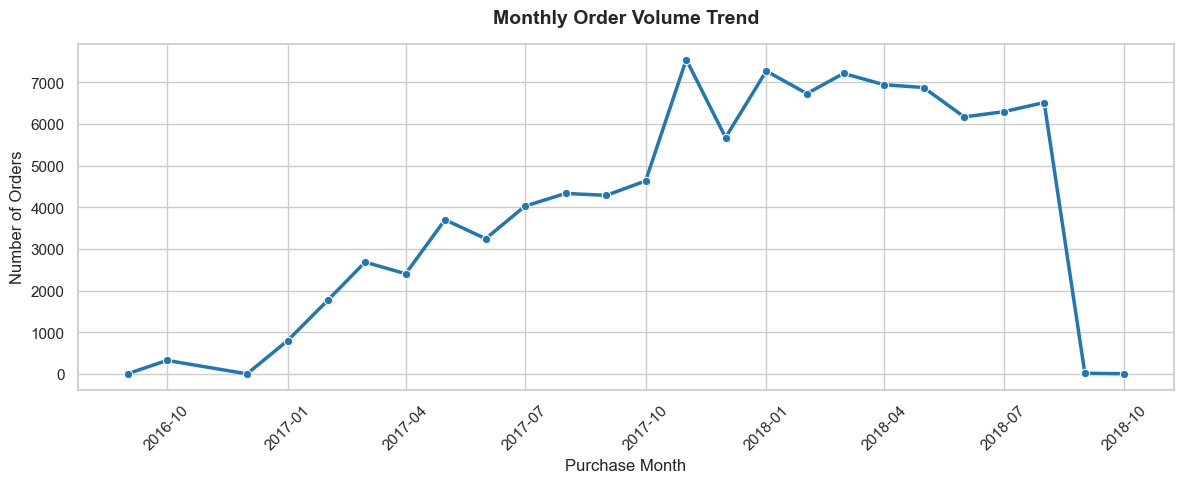

In [48]:
# Set a clean visual theme for the plots
sns.set_theme(style="whitegrid")

# Extract the Year-Month period and convert it to a timestamp for plotting
df_orders['purchase_month'] = df_orders['order_purchase_date'].dt.to_period('M')
monthly_orders = df_orders.groupby('purchase_month').size().reset_index(name='order_count')
monthly_orders['purchase_month'] = monthly_orders['purchase_month'].dt.to_timestamp()

# Plot the monthly order counts
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_orders, 
    x='purchase_month', 
    y='order_count', 
    marker='o', 
    color='#1f77b4', 
    linewidth=2.5
)
plt.title('Monthly Order Volume Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Purchase Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 1.2. Distribution of Order Statuses

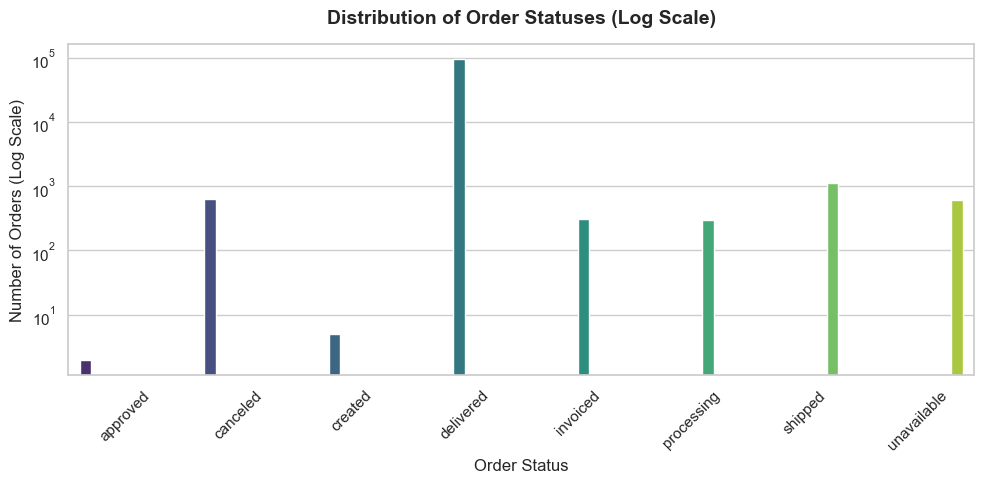

In [49]:
# Get counts of each status and sort them
status_counts = df_orders['order_status'].value_counts().reset_index(name='count')

plt.figure(figsize=(10, 5))

# Using a log scale for the y-axis because 'delivered' completely dominates the other statuses
ax = sns.barplot(
    data=status_counts, 
    x='order_status', 
    y='count', 
    hue='order_status', 
    palette='viridis', 
    legend=False
)
ax.set_yscale('log')
plt.title('Distribution of Order Statuses (Log Scale)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Order Status', fontsize=12)
plt.ylabel('Number of Orders (Log Scale)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2. Exploring Order Items Table :

#### 2.1. Product Price and Freight Cost Distributions

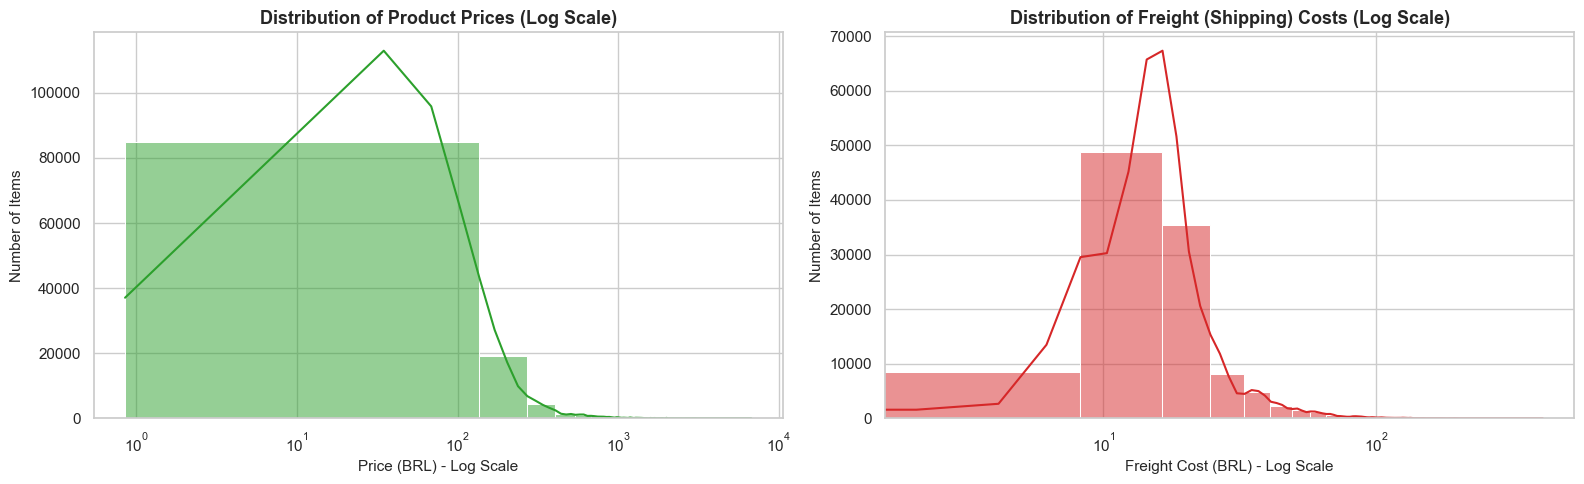

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Product Price Distribution (using log scale)
sns.histplot(
    data=df_order_items, 
    x='price', 
    bins=50, 
    kde=True, 
    ax=axes[0], 
    color='#2ca02c'
)
axes[0].set_xscale('log')
axes[0].set_title('Distribution of Product Prices (Log Scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (BRL) - Log Scale', fontsize=11)
axes[0].set_ylabel('Number of Items', fontsize=11)

# Plot Freight (Shipping) Cost Distribution (using log scale)
sns.histplot(
    data=df_order_items, 
    x='freight_value', 
    bins=50, 
    kde=True, 
    ax=axes[1], 
    color='#d62728'
)
axes[1].set_xscale('log')
axes[1].set_title('Distribution of Freight (Shipping) Costs (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Freight Cost (BRL) - Log Scale', fontsize=11)
axes[1].set_ylabel('Number of Items', fontsize=11)

plt.tight_layout()
plt.show()



#### 2.2. Number of Items Purchased per Order

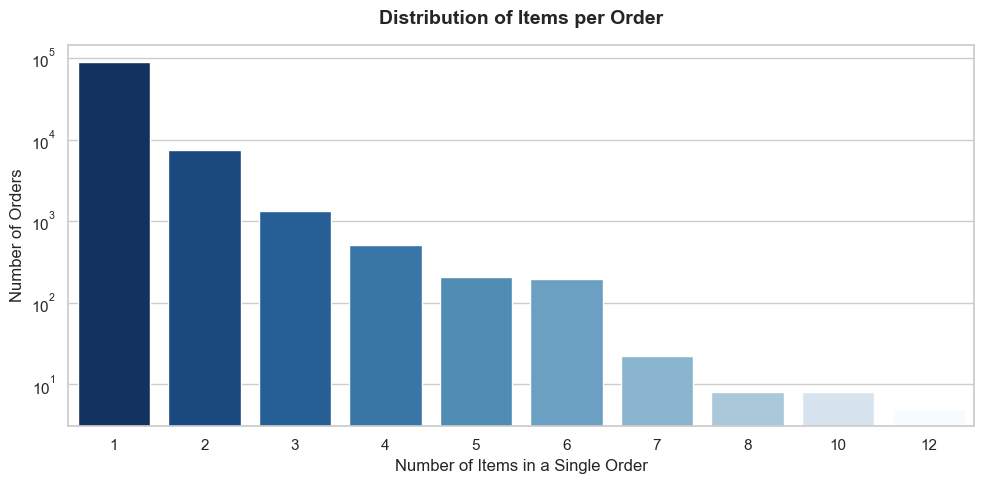

In [51]:
# Group by order_id to count the items in each order
items_per_order = df_order_items.groupby('order_id').size().reset_index(name='item_count')
items_summary = items_per_order['item_count'].value_counts().reset_index(name='order_count')

plt.figure(figsize=(10, 5))
# Show the top item counts (excluding extremely rare outliers for clarity)
axe = sns.barplot(
    data=items_summary.head(10), 
    x='item_count', 
    y='order_count', 
    hue='item_count',
    palette='Blues_r',
    legend=False
)
axe.set_yscale('log')
plt.title('Distribution of Items per Order', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Items in a Single Order', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.tight_layout()
plt.show()


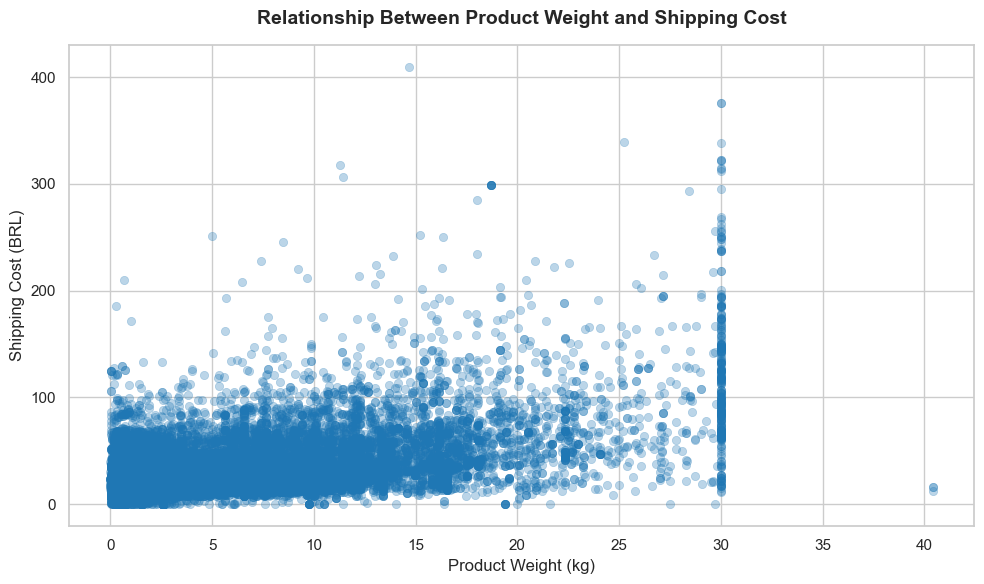

In [52]:

# 1. Join order items and products to bring in the product weight
df_items_weight = df_order_items.merge(
    df_products[['product_id', 'product_weight_g']], 
    on='product_id', 
    how='left'
)

# Convert grams to kilograms for better readability on the plot
df_items_weight['product_weight_kg'] = df_items_weight['product_weight_g'] / 1000.0

# 2. Plot the scatter plot
plt.figure(figsize=(10, 6))

# Using alpha=0.3 (transparency) to prevent overplotting (overlapping dots)
sns.scatterplot(
    data=df_items_weight, 
    x='product_weight_kg', 
    y='freight_value', 
    alpha=0.3, 
    color='#1f77b4',
    edgecolor=None
)

plt.title('Relationship Between Product Weight and Shipping Cost', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Weight (kg)', fontsize=12)
plt.ylabel('Shipping Cost (BRL)', fontsize=12)

plt.tight_layout()
plt.show()


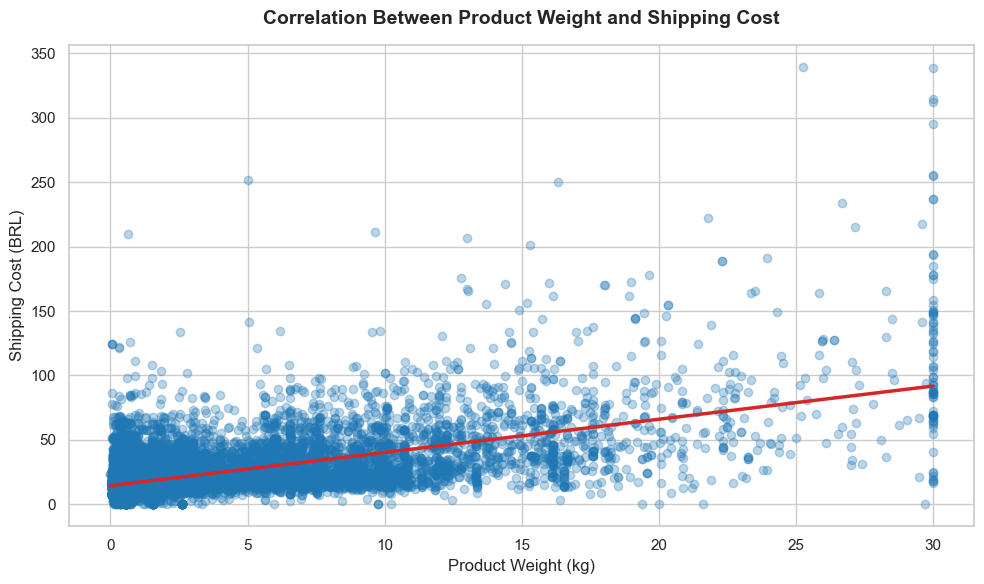

In [53]:
# 1. Join tables if you haven't done so in a previous cell
df_items_weight = df_order_items.merge(
    df_products[['product_id', 'product_weight_g']], 
    on='product_id', 
    how='left'
)
df_items_weight['product_weight_kg'] = df_items_weight['product_weight_g'] / 1000.0

# 2. Take a random sample of the data for better performance and visual clarity
df_sample = df_items_weight.sample(n=30000, random_state=42)

# 3. Plot the scatter plot with the correlation line
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_sample, 
    x='product_weight_kg', 
    y='freight_value',
    scatter_kws={'alpha': 0.3, 'color': '#1f77b4', 'edgecolor': None}, # Style for scatter dots
    line_kws={'color': '#d62728', 'linewidth': 2.5},                  # Style for the correlation line
    ci=None                                                            # Disables slow bootstrap calculations
)

plt.title('Correlation Between Product Weight and Shipping Cost', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Weight (kg)', fontsize=12)
plt.ylabel('Shipping Cost (BRL)', fontsize=12)

plt.tight_layout()
plt.show()


### 3. Exploring Order Payment table :

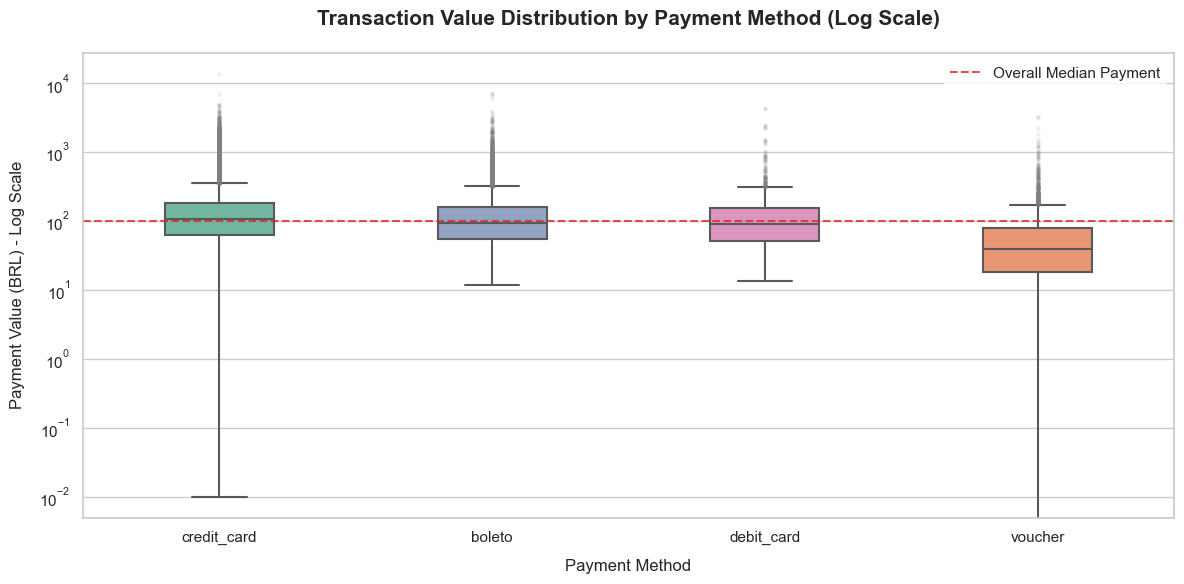

In [54]:
# 1. Clean the payment data and convert to string to remove unused categories on the x-axis
df_clean_payments = df_order_payments[df_order_payments['payment_type'] != 'not_defined'].copy()
df_clean_payments['payment_type'] = df_clean_payments['payment_type'].astype(str)

# 2. Sort the categories on the x-axis by their median payment value (highest to lowest)
order = df_clean_payments.groupby('payment_type')['payment_value'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))

# 3. Create the enhanced box plot
sns.boxplot(
    data=df_clean_payments,
    x='payment_type',
    y='payment_value',
    order=order,
    width=0.4,                           # Narrower boxes for a cleaner look
    hue='payment_type',
    palette='Set2',                      # Harmonious color palette
    legend=False,
    linewidth=1.5,
    fliersize=3,                         # Smaller outlier dots
    flierprops={                         # Make outlier dots soft and semi-transparent
        'marker': 'o',
        'markerfacecolor': 'gray',
        'markeredgecolor': 'none',
        'alpha': 0.15
    }
)

# Apply a log scale to the y-axis
plt.yscale('log')

# 4. Add a horizontal baseline showing the overall median payment value
overall_median = df_clean_payments['payment_value'].median()
plt.axhline(
    overall_median, 
    color='#d62728', 
    linestyle='--', 
    linewidth=1.5, 
    alpha=0.8, 
    label='Overall Median Payment'
)

# 5. Fine-tune labels and titles
plt.title('Transaction Value Distribution by Payment Method (Log Scale)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Payment Method', fontsize=12, labelpad=10)
plt.ylabel('Payment Value (BRL) - Log Scale', fontsize=12, labelpad=10)

# Display the legend for the baseline reference
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()


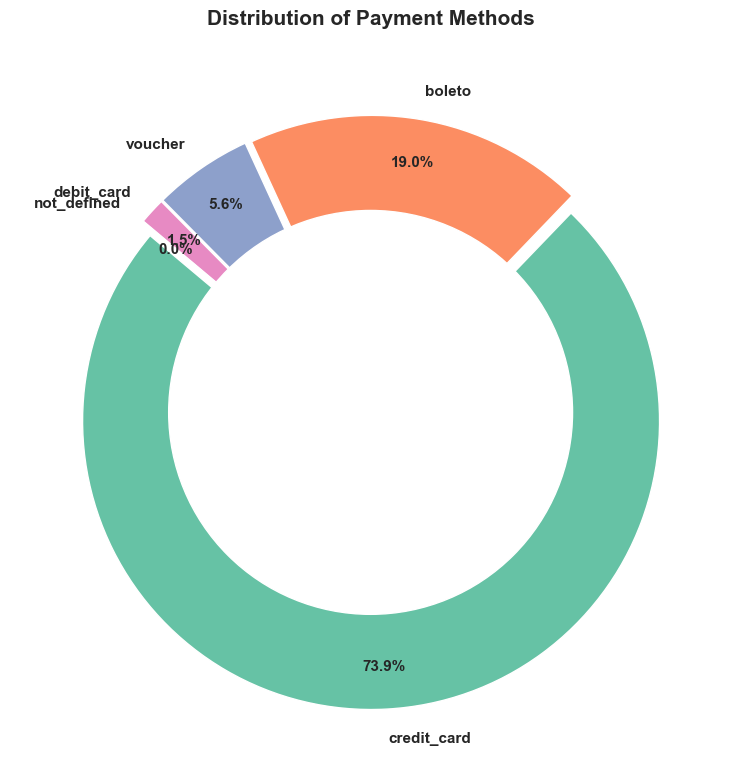

In [55]:
# 1. Clean the payment data by excluding 'not_defined'
df_clean_payments = df_order_payments[df_order_payments['payment_type'] != 'not_defined'].copy()
payment_counts = df_clean_payments['payment_type'].value_counts()

# 2. Set up the figure canvas
plt.figure(figsize=(8, 8))

# Use a harmonious color palette
colors = sns.color_palette('Set2', len(payment_counts))

# Slightly separate each slice for a clean look
explode = [0.03] * len(payment_counts)

# 3. Plot the pie chart
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',                  # Show percentages on the slices
    startangle=140,                     # Rotate starting angle for aesthetic balance
    colors=colors,
    pctdistance=0.85,                   # Position percentages inside the slices
    explode=explode,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# 4. Draw a white circle in the center to turn the pie chart into a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Adjust title and layout
plt.title('Distribution of Payment Methods', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


### 4. Exploring Order Reviews table :

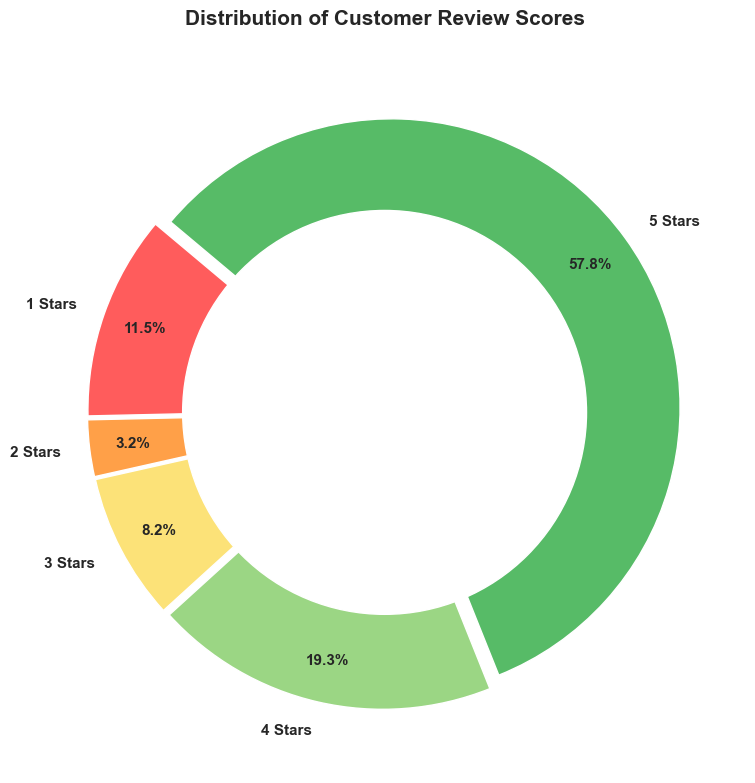

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Deduplicate by review_id and get the counts of each score (sorted from 1 to 5 stars)
df_unique_reviews = df_order_reviews.drop_duplicates(subset=['review_id']).copy()
score_counts = df_unique_reviews['review_score'].value_counts().sort_index()

# 2. Define custom colors (Green for 5 stars, graduating to Red for 1 star)
colors = ['#ff5c5c', '#ffa048', '#fce278', '#9bd684', '#57bb67']  # 1 Star to 5 Stars

# Slightly separate all slices for a clean, modern design
explode = [0.03] * len(score_counts)

# 3. Plot the pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    score_counts,
    labels=[f'{idx} Stars' for idx in score_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    explode=explode,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# 4. Draw a white circle in the center to convert the pie chart to a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Customer Review Scores', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


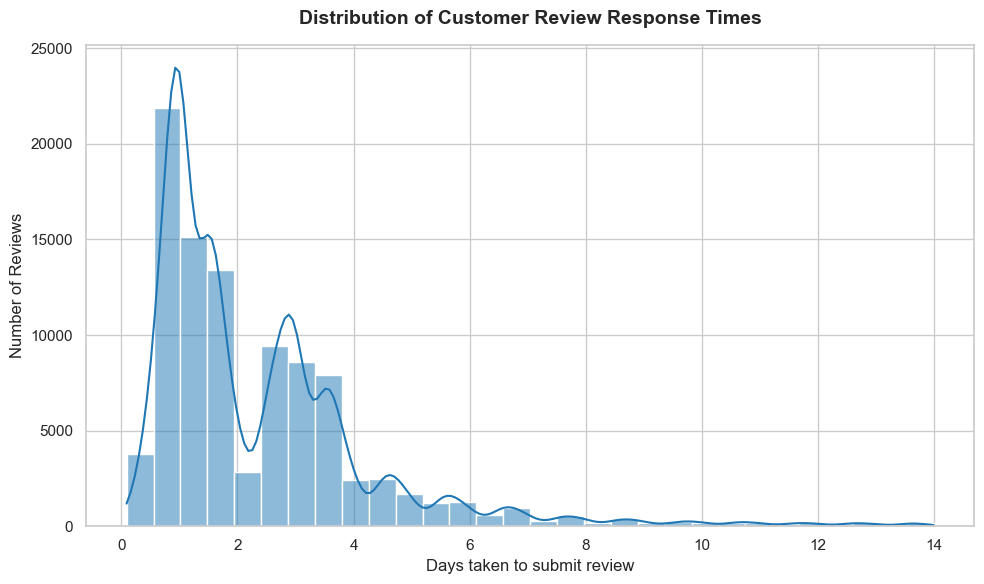

In [57]:
# Set style
sns.set_theme(style="whitegrid")

# 1. Deduplicate reviews and convert date columns to datetime objects
df_unique_reviews = df_order_reviews.drop_duplicates(subset=['review_id']).copy()

df_unique_reviews['review_creation_date'] = pd.to_datetime(
    df_unique_reviews['review_creation_date'], 
    dayfirst=True
)
# Using review_answer_date instead of review_answer_timestamp
df_unique_reviews['review_answer_date'] = pd.to_datetime(
    df_unique_reviews['review_answer_date'], 
    dayfirst=True
)

# 2. Calculate the response time in days
df_unique_reviews['response_time_days'] = (
    df_unique_reviews['review_answer_date'] - df_unique_reviews['review_creation_date']
).dt.total_seconds() / 86400.0  # Convert seconds to days

# 3. Plot the histogram
plt.figure(figsize=(10, 6))

# Filter the data to show response times up to 14 days for a clean, focused look
sns.histplot(
    data=df_unique_reviews[df_unique_reviews['response_time_days'] <= 14],
    x='response_time_days',
    bins=30,
    kde=True,
    color='#1f77b4',
    edgecolor='white'
)

plt.title('Distribution of Customer Review Response Times', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Days taken to submit review', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

plt.tight_layout()
plt.show()

### Phase 3 : Statistical tests 

#### Test 1: Product Weight vs. Shipping Cost (Pearson Correlation Test)

Business Question: Does the weight of a product linearly correlate with its shipping cost?

$H_0$ (Null Hypothesis): There is no linear correlation between product weight and shipping cost.
$H_1$ (Alternative Hypothesis): There is a statistically significant linear correlation between product weight and shipping cost.

In [58]:
import scipy.stats as stats

# 1. Ensure the merged weight data is prepared
df_items_weight = df_order_items.merge(
    df_products[['product_id', 'product_weight_g']], 
    on='product_id', 
    how='left'
)
df_corr_clean = df_items_weight[['product_weight_g', 'freight_value']].dropna()

# 2. Perform the Pearson Correlation Test
correlation_coef, p_value = stats.pearsonr(
    df_corr_clean['product_weight_g'], 
    df_corr_clean['freight_value']
)

# 3. Output the results
print("--- Pearson Correlation Test Results ---")
print(f"Correlation Coefficient (r): {correlation_coef:.4f}")
print(f"P-value: {p_value:.4e}")

# 4. Evaluate the hypothesis
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis (H0).")
    print("Conclusion: There is a statistically significant correlation between product weight and shipping cost.")
else:
    print("\nResult: Fail to reject the Null Hypothesis (H0).")
    print("Conclusion: There is no statistically significant correlation between product weight and shipping cost.")


--- Pearson Correlation Test Results ---
Correlation Coefficient (r): 0.6104
P-value: 0.0000e+00

Result: Reject the Null Hypothesis (H0).
Conclusion: There is a statistically significant correlation between product weight and shipping cost.


#### Test 2: Payment Method vs. Transaction Value (One-Way ANOVA & Kruskal-Wallis)

Business Question: Does the average transaction amount differ significantly depending on the payment method used?

$H_0$ (Null Hypothesis): The average transaction value is equal across all payment methods.
$H_1$ (Alternative Hypothesis): At least one payment method has a different average transaction value.
Note: Since e-commerce transaction values are typically skewed, we run both the ANOVA (parametric) and the Kruskal-Wallis (non-parametric) tests to ensure robust validation.

In [59]:
# 1. Prepare payment groups (excluding 'not_defined')
df_anova_clean = df_order_payments[df_order_payments['payment_type'] != 'not_defined'].copy()
payment_groups = [
    group['payment_value'].values 
    for name, group in df_anova_clean.groupby('payment_type')
]

# 2. Run the parametric One-Way ANOVA test
f_stat, p_value_anova = stats.f_oneway(*payment_groups)

# 3. Run the non-parametric Kruskal-Wallis test (robust to outliers and skewness)
h_stat, p_value_kruskal = stats.kruskal(*payment_groups)

# 4. Output the results
print("--- Statistical Test Results ---")
print(f"ANOVA F-Statistic: {f_stat:.4f} | P-value: {p_value_anova:.4e}")
print(f"Kruskal-Wallis H-Statistic: {h_stat:.4f} | P-value: {p_value_kruskal:.4e}")

# 5. Evaluate the hypothesis (using Kruskal-Wallis as the primary metric due to log-scale distribution)
alpha = 0.05
if p_value_kruskal < alpha:
    print("\nResult: Reject the Null Hypothesis (H0).")
    print("Conclusion: There is a statistically significant difference in transaction values across different payment methods.")
else:
    print("\nResult: Fail to reject the Null Hypothesis (H0).")
    print("Conclusion: There is no statistically significant difference in transaction values across payment methods.")


--- Statistical Test Results ---
ANOVA F-Statistic: 380.9981 | P-value: 0.0000e+00
Kruskal-Wallis H-Statistic: 5490.5005 | P-value: 0.0000e+00

Result: Reject the Null Hypothesis (H0).
Conclusion: There is a statistically significant difference in transaction values across different payment methods.


#### Test 3: Payment Method vs. Customer Satisfaction (Chi-Square Test)

Business Question: Is a customer's satisfaction level (Satisfied vs. Unsatisfied) associated with the payment method they used?

$H_0$ (Null Hypothesis): Customer satisfaction category is independent of the payment method used.
$H_1$ (Alternative Hypothesis): Customer satisfaction category is dependent on the payment method used.
Run this code in a new cell:

In [60]:
# 1. Merge deduplicated reviews with payment methods on order_id
df_reviews_unique = df_order_reviews.drop_duplicates(subset=['review_id'])
df_satisfaction = df_reviews_unique.merge(
    df_order_payments[['order_id', 'payment_type']], 
    on='order_id', 
    how='inner'
)
df_satisfaction = df_satisfaction[df_satisfaction['payment_type'] != 'not_defined']

# 2. Segment review scores into 'Satisfied' (4-5 stars) and 'Unsatisfied' (1-3 stars)
df_satisfaction['satisfaction_status'] = df_satisfaction['review_score'].apply(
    lambda x: 'Satisfied' if x >= 4 else 'Unsatisfied'
)

# 3. Generate the contingency table
contingency_table = pd.crosstab(
    df_satisfaction['satisfaction_status'], 
    df_satisfaction['payment_type']
)
print("--- Contingency Table ---")
print(contingency_table)
print("-" * 30)

# 4. Perform the Chi-Square Test of Independence
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# 5. Output the results
print(f"\nChi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Degrees of Freedom: {dof}")

# 6. Evaluate the hypothesis
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis (H0).")
    print("Conclusion: Customer satisfaction is dependent on the payment method used.")
else:
    print("\nResult: Fail to reject the Null Hypothesis (H0).")
    print("Conclusion: Customer satisfaction is independent of the payment method used.")


--- Contingency Table ---
payment_type         boleto  credit_card  debit_card  voucher
satisfaction_status                                          
Satisfied             15102        58680        1207     4266
Unsatisfied            4495        17314         314     1448
------------------------------

Chi-Square Statistic: 24.2232
P-value: 2.2438e-05
Degrees of Freedom: 3

Result: Reject the Null Hypothesis (H0).
Conclusion: Customer satisfaction is dependent on the payment method used.
